# 统计与大数据分析 · 第二次作业：条件概率与 Monte Carlo

**题目**：连续掷两次公平六面骰子。令

- $A$：第一次为 6；
- $B$：两次点数之和为 9。

要求：

1. 用条件概率定义解析计算 $P(A\mid B)$；
2. 用 Python 随机模拟估计 $P(A\mid B)$；
3. 分别取 $N=10^2,\,10^3,\,10^4,\,10^5$，比较模拟结果；
4. 解释为什么增加 $N$ 不保证每一次模拟结果都比前一次更接近理论值。

本作业按"**概率模型 → 解析推导 → 蒙特卡洛模拟 → 一致性检验 → 解释**"的顺序展开。

In [1]:
# 导入所需的包：numpy 负责随机模拟与数值计算，matplotlib.pyplot 负责绘图
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# 让图中的中文能够正常显示（与 hw1 相同的字体设置）
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "PingFang SC",
    "Noto Sans CJK SC",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "cm"

# 解析结果与渐近标准差常数（第 5 节用 Delta 方法推导）：
#   P(A|B) = 1/4，且 sd(p̂) ≈ 1.299 / sqrt(N)
P_THEORY = 1 / 4
SIGMA_THEORY = 3 * np.sqrt(3) / 4

## 1. 概率模型与事件定义

**样本空间。** 把每次实验的结果记为一个有序对 $(i,j)$，其中 $i$ 是第一次点数，$j$ 是第二次点数：

$$\Omega=\{(i,j): i,j\in\{1,2,\dots,6\}\},\qquad |\Omega|=36 .$$

**基本假设**：

1. **公平性**：骰子每个面出现的概率都是 $1/6$；
2. **独立性**：两次投掷相互独立。

由 1 与 2 得到**乘积概率模型**：对每个有序结果 $(i,j)$，

$$P\{(i,j)\}=P(\text{第一次为}\ i)\,P(\text{第二次为}\ j)=\frac16\cdot\frac16=\frac1{36}.$$

也就是说，36 个有序结果**等可能**，概率各为 $1/36$。这一步是下面"数结果个数"做法的合法性来源——如果没有公平性或不独立，36 个结果就不等可能，直接数个数会得出错误的概率。

**事件定义与枚举**：

| 事件 | 含义 | 包含的结果 | 个数 |
| --- | --- | --- | --- |
| $A$ | 第一次为 6 | $(6,1),(6,2),\dots,(6,6)$ | 6 |
| $B$ | 两次点数之和为 9 | $(3,6),(4,5),(5,4),(6,3)$ | 4 |
| $A\cap B$ | 和为 9 且第一次为 6 | $(6,3)$ | 1 |

注意 $A\cap B\subseteq B$：只有在"和为 9"发生的前提下，才谈得上 $A$ 是否发生。

**条件概率的定义**：当 $P(B)>0$ 时，

$$P(A\mid B)=\frac{P(A\cap B)}{P(B)} .$$

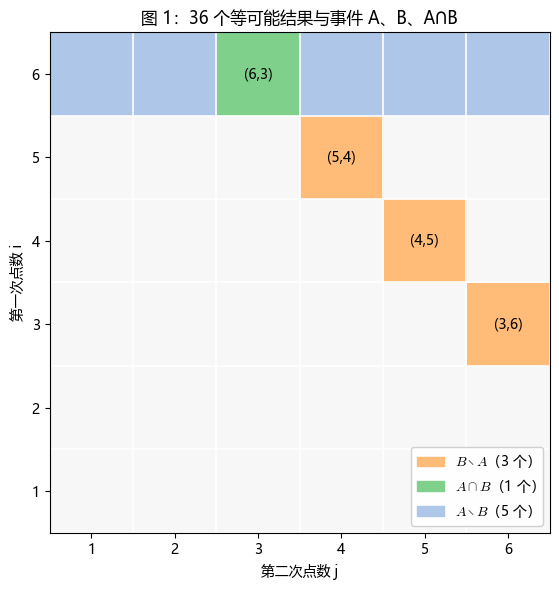

In [2]:
# 把 36 个结果画成 6×6 的方格图：横轴 = 第二次点数 j，纵轴 = 第一次点数 i。
# 颜色编码：橙色 = B 中不属于 A 的 3 个；绿色 = A∩B 的 1 个；蓝色 = A 中不属于 B 的 5 个。
kind = np.zeros((6, 6), dtype=int)  # 0 = 其他, 1 = B\A, 2 = A∩B, 3 = A\B
for i in range(1, 7):        # i：第一次点数
    for j in range(1, 7):    # j：第二次点数
        if i + j == 9 and i == 6:
            kind[i - 1, j - 1] = 2
        elif i + j == 9:
            kind[i - 1, j - 1] = 1
        elif i == 6:
            kind[i - 1, j - 1] = 3

cmap = ListedColormap(["#f7f7f7", "#ffbb78", "#7fd08a", "#aec7e8"])

fig, ax = plt.subplots(figsize=(6.2, 6))
ax.imshow(kind, cmap=cmap, origin="lower", extent=(0.5, 6.5, 0.5, 6.5), vmin=0, vmax=3)

# 画格线
ax.vlines(np.arange(0.5, 7, 1), 0.5, 6.5, color="white", linewidth=1.2)
ax.hlines(np.arange(0.5, 7, 1), 0.5, 6.5, color="white", linewidth=1.2)

# 在事件 B 的 4 个结果上标出 (第一次点数, 第二次点数)
for i, j in [(3, 6), (4, 5), (5, 4), (6, 3)]:
    ax.text(j, i, f"({i},{j})", ha="center", va="center", fontsize=10)

ax.set_xticks(range(1, 7))
ax.set_yticks(range(1, 7))
ax.set_xlabel("第二次点数 j")
ax.set_ylabel("第一次点数 i")
ax.set_title("图 1：36 个等可能结果与事件 A、B、A∩B")
ax.legend(
    handles=[
        Patch(color="#ffbb78", label=r"$B\setminus A$（3 个）"),
        Patch(color="#7fd08a", label=r"$A\cap B$（1 个）"),
        Patch(color="#aec7e8", label=r"$A\setminus B$（5 个）"),
    ],
    loc="lower right",
    fontsize=10,
    framealpha=0.9,
)
fig.tight_layout()
plt.show()

### 图 1 的内容解释

- **每个格子**：一个有序结果 $(i,j)$，横轴是第二次点数、纵轴是第一次点数。由公平性 + 独立性，36 个格子各占概率 $1/36$。
- **绿色格子（$A\cap B$）**：唯一结果 $(6,3)$，占 $1/36$。
- **橙色格子（$B\setminus A$）**：$(3,6),(4,5),(5,4)$，占 $3/36$。
- **蓝色格子（$A\setminus B$）**：$(6,1),(6,2),(6,4),(6,5),(6,6)$，占 $5/36$。
- 事件 $B$ 是"橙色 + 绿色"共 4 个格子；其中绿色占 1 个。按条件概率定义
  $$P(A\mid B)=\frac{P(A\cap B)}{P(B)}=\frac{1/36}{4/36}=\frac14,$$
  等价地，"只看 $B$ 的 4 个格子，绿色占 $1/4$"。
- **对照无条件概率**：不加条件时，$A$ 占全部 36 格中的 6 格，$P(A)=1/6$；限定在 $B$ 的 4 格后，$A$ 的机会升到 $1/4$。可见条件化改变了 $A$ 的概率，$A$ 与 $B$ 不独立。

## 2. 用条件概率定义解析计算 $P(A\mid B)$

**第一步：算分母 $P(B)$。** 由 36 个结果等可能，

$$P(B)=\frac{|B|}{36}=\frac{4}{36}=\frac19 .$$

**第二步：算分子 $P(A\cap B)$。** 同理

$$P(A\cap B)=\frac{|A\cap B|}{36}=\frac{1}{36}.$$

**第三步：代入条件概率的定义。**

$$P(A\mid B)=\frac{P(A\cap B)}{P(B)}=\frac{1/36}{4/36}=\frac14=0.25 .$$

**验证 $A$ 与 $B$ 不独立：**

$$P(A\cap B)=\frac{1}{36}\ \ne\ P(A)\,P(B)=\frac16\cdot\frac19=\frac{1}{54}.$$

如果 $A$、$B$ 独立，应该有 $P(A\mid B)=P(A)=1/6$；实际上 $P(A\mid B)=1/4>1/6$，即"已知和为 9"**提高**了"第一次为 6"的概率，因为和为 9 必须由大小点数搭配而成，一旦发生，第一次恰好是 6 的机会就不再是 $1/6$ 那么小。

**理论基准值**：$P(A\mid B)=1/4=0.25$，它是后面所有模拟结果比较的参照。

## 3. 用随机模拟估计 $P(A\mid B)$

**估计量。** 独立重复"掷两次骰子"这一实验 $N$ 次（$N$ 次实验之间也相互独立），记

- $K_B$：两次点数之和为 9（即 $B$ 发生）的次数；
- $K_{AB}$：和为 9 且第一次为 6（即 $A\cap B$ 发生）的次数。

由 $P(A\mid B)=P(A\cap B)/P(B)$，自然的蒙特卡洛估计量是**两个频率之比**：

$$\hat p_N=\frac{K_{AB}/N}{K_B/N}=\frac{K_{AB}}{K_B}.$$

这相当于**拒绝采样**：先按联合分布掷出全部 $N$ 个样本，再只保留落在 $B$ 中的样本用来看 $A$ 的频率。

**收敛性的说明** 每个样本的指示变量独立同分布，由强大数定律，

$$\frac{K_{AB}}{N}\xrightarrow{\ \text{a.s.}\ }P(A\cap B),\qquad
\frac{K_B}{N}\xrightarrow{\ \text{a.s.}\ }P(B)=\frac19>0,$$

分母几乎必然不为 0，由连续映射定理，二者之比的极限为

$$\hat p_N\ \xrightarrow{\ \text{a.s.}\ }\frac{P(A\cap B)}{P(B)}=\frac14 .$$

这里用到的独立性是"**$N$ 次重复实验相互独立**"，这是蒙特卡罗方法成立的基石。

In [3]:
def simulate_conditional(N, rng):
    """掷 N 对公平骰子，返回 (p_hat, K_B, K_AB)。"""
    d1 = rng.integers(1, 7, size=N, dtype=np.int8)   # 第一次投掷
    d2 = rng.integers(1, 7, size=N, dtype=np.int8)   # 第二次投掷
    in_B = (d1 + d2) == 9                            # 事件 B：两次点数之和为 9
    in_AB = in_B & (d1 == 6)                         # 事件 A∩B：和为 9 且第一次为 6
    K_B = int(in_B.sum())
    K_AB = int(in_AB.sum())
    p_hat = K_AB / K_B if K_B > 0 else float("nan")  # K_B = 0 的极端情形（概率极小）
    return p_hat, K_B, K_AB


Ns = [10**2, 10**3, 10**4, 10**5]
rng = np.random.default_rng(2026)                    # 固定种子，保证结果可复现

single_run = []                                      # 记录四个 N 的单次实验结果
print(f"{'N':>7} {'K_B':>7} {'K_AB':>6} {'p_hat':>8} {'|error|':>9}")
for N in Ns:
    p_hat, K_B, K_AB = simulate_conditional(N, rng)
    single_run.append((N, p_hat, K_B, K_AB))
    print(f"{N:>7} {K_B:>7} {K_AB:>6} {p_hat:>8.4f} {abs(p_hat - P_THEORY):>9.4f}")
print(f"\n理论值 P(A|B) = {P_THEORY:.4f}")

      N     K_B   K_AB    p_hat   |error|
    100      10      3   0.3000    0.0500
   1000     109     35   0.3211    0.0711
  10000    1113    308   0.2767    0.0267
 100000   11146   2820   0.2530    0.0030

理论值 P(A|B) = 0.2500


### 单次实验结果的比较

上表（$K_B$ 为"和为 9"的样本数，$K_{AB}$ 为其"第一次为 6"的样本数，$\hat p_N=K_{AB}/K_B$）是固定种子下的一次实验：

| $N$ | $\hat p_N$ | 与 $1/4$ 的偏差 | 渐近波动带 $\pm2\times1.299/\sqrt N$ |
| --- | --- | --- | --- |
| $10^2$ | $0.3000$ | $0.0500$ | $\pm 0.260$ |
| $10^3$ | $0.3211$ | $0.0711$ | $\pm 0.082$ |
| $10^4$ | $0.2767$ | $0.0267$ | $\pm 0.026$ |
| $10^5$ | $0.2530$ | $0.0030$ | $\pm 0.008$ |

观察到的现象：

- 四个估计都在 $0.25$ 附近，但**明显不单调**：从 $N=10^2$ 到 $N=10^3$，偏差反而从 $0.050$ 上升到 $0.071$——这正是第 4 问所说的"增加 $N$ 不保证更接近"的一次真实发生。
- 总体趋势上估计值仍随 $N$ 增大向 $0.25$ 靠拢（$N=10^5$ 时偏差降到 $0.003$），且始终落在各自的 $2$ 倍渐近标准差带内。
- 关键原因：每个 $N$ 的结果都是**独立实验**产生的随机数，$N$ 更大的那次实验并不"继承"小 $N$ 实验的信息，没有任何机制保证估计值逐次变准。

图 2 把四个估计值连同各自的**渐近波动带**画在一起：真正随 $N$ 稳定变化的是这条带子的宽度（按 $1/\sqrt N$ 收窄），而不是某一次的具体数值。

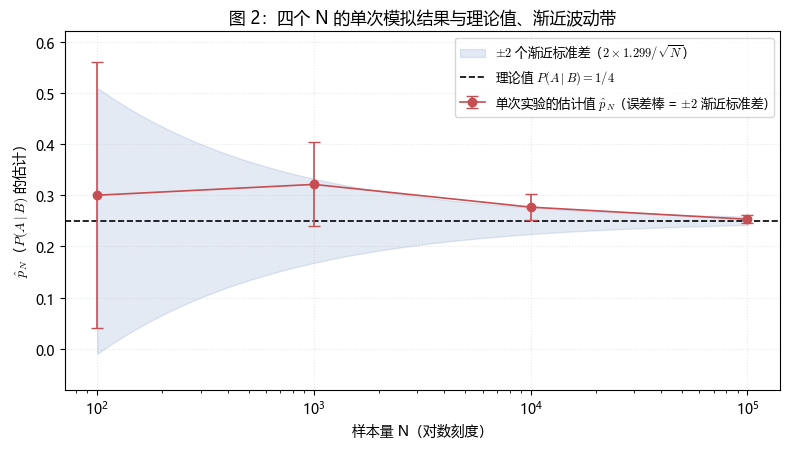

In [4]:
N_grid = np.logspace(2, 5, 200)
N_arr = np.array(Ns, dtype=float)
p_arr = np.array([p for _, p, _, _ in single_run])

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.fill_between(
    N_grid,
    P_THEORY - 2 * SIGMA_THEORY / np.sqrt(N_grid),
    P_THEORY + 2 * SIGMA_THEORY / np.sqrt(N_grid),
    color="#4c72b0",
    alpha=0.15,
    label=r"$\pm 2$ 个渐近标准差（$2\times 1.299/\sqrt{N}$）",
)
ax.axhline(P_THEORY, color="black", linestyle="--", linewidth=1.2,
           label=r"理论值 $P(A\mid B)=1/4$")
ax.errorbar(
    N_arr, p_arr,
    yerr=2 * SIGMA_THEORY / np.sqrt(N_arr),
    fmt="o-", color="#c44e52", capsize=4, linewidth=1.2,
    label=r"单次实验的估计值 $\hat p_N$（误差棒 = $\pm 2$ 渐近标准差）",
)
ax.set_xscale("log")
ax.set_xlabel("样本量 N（对数刻度）")
ax.set_ylabel(r"$\hat p_N$（$P(A\mid B)$ 的估计）")
ax.set_title("图 2：四个 N 的单次模拟结果与理论值、渐近波动带")
ax.set_ylim(-0.08, 0.62)
ax.grid(alpha=0.3, linestyle=":")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

### 图 2 的内容解释

- **红色折线**：四个 $N$ 的单次估计值 $\hat p_N$；可见它在 $1/4$ 附近抖动，且先升后降，并不单调。
- **黑色虚线**：理论值 $1/4$。
- **蓝色阴影带**：渐近波动带 $\pm2\times1.299/\sqrt N$，宽度按 $1/\sqrt N$ 收窄。
- **读法**：单次估计"落在哪里"是随机的，但**波动带的宽度**随 $N$ 稳定收缩——这才是"增大 $N$ 提高精度"的严格含义。

## 4. 重复实验：波动幅度与收敛速度

单次实验只能说明"估计值落在真值附近"，要检验 $N$ 的作用，需要对每个 $N$ **独立重复** $R$ 次实验，得到 $R$ 个估计 $\hat p_N^{(1)},\dots,\hat p_N^{(R)}$，看三个量：

- **经验均值** $\bar p_N$：应接近 $1/4$；
- **经验标准差**：应接近理论值 $1.299/\sqrt N$（第 5 节推导）；
- **RMSE** $=\sqrt{\frac1R\sum_{r}(\hat p_N^{(r)}-1/4)^2}$：偏差可忽略时应与标准差同量级。

由于 $N$ 越大单次实验越贵，取 $R=2000,\,2000,\,1000,\,400$；并用均值的 $95\%$ 置信区间 $\bar p_N\pm1.96\,s/\sqrt R$ 检验它是否覆盖 $1/4$，用"落在 $\pm2$ 个渐近标准差内的比例"检验正态近似（理论覆盖率 $\approx0.9545$）。

In [5]:
reps_per_N = {10**2: 2000, 10**3: 2000, 10**4: 1000, 10**5: 400}
rng_reps = np.random.default_rng(2027)   # 与单次实验相互独立

estimates = {}
for N, R in reps_per_N.items():
    vals = np.empty(R)
    for r in range(R):
        vals[r] = simulate_conditional(N, rng_reps)[0]
    estimates[N] = vals

print(f"{'N':>7} {'R':>5} {'mean':>7} {'sd':>7} {'sd_theory':>10} {'RMSE':>7} "
      f"{'coverage(2sd)':>14} {'95% CI for mean':>22} {'covers':>6}")
for N, vals in estimates.items():
    R = len(vals)
    m, s = vals.mean(), vals.std(ddof=1)
    sd_th = SIGMA_THEORY / np.sqrt(N)
    rmse = np.sqrt(np.mean((vals - P_THEORY) ** 2))
    cov = np.mean(np.abs(vals - P_THEORY) <= 2 * sd_th)
    lo, hi = m - 1.96 * s / np.sqrt(R), m + 1.96 * s / np.sqrt(R)
    covers = "yes" if lo <= P_THEORY <= hi else "no"
    print(f"{N:>7} {R:>5} {m:>7.4f} {s:>7.4f} {sd_th:>10.4f} {rmse:>7.4f} "
          f"{cov:>14.3f} [{lo:>7.4f}, {hi:>7.4f}] {covers:>6}")

      N     R    mean      sd  sd_theory    RMSE  coverage(2sd)        95% CI for mean covers
    100  2000  0.2492  0.1347     0.1299  0.1346          0.970 [ 0.2433,  0.2551]    yes
   1000  2000  0.2505  0.0407     0.0411  0.0407          0.954 [ 0.2487,  0.2523]    yes
  10000  1000  0.2495  0.0129     0.0130  0.0129          0.956 [ 0.2487,  0.2503]    yes
 100000   400  0.2501  0.0042     0.0041  0.0042          0.943 [ 0.2497,  0.2505]    yes


### 上表怎么读

- **均值**：四个 $N$ 的重复实验均值 $0.2492,\ 0.2505,\ 0.2495,\ 0.2501$ 都紧贴 $1/4$，且四个 $95\%$ 置信区间**全部覆盖** $1/4$——模拟没有可检出的系统性偏差。
- **标准差**：经验标准差 $0.1347,\ 0.0407,\ 0.0129,\ 0.0042$ 与渐近理论值 $1.299/\sqrt N$（$0.1299,\ 0.0411,\ 0.0130,\ 0.0041$）基本一致。$N=10^2$ 时经验值比渐近值大约 $4\%$，这不是模拟出错：按第 5 节末尾的精确计算，$N=10^2$ 的真实标准差应为 $0.1362$（比渐近值大 $5\%$），观测值 $0.1347$ 落在两者之间、更贴近精确值。$N\ge10^3$ 后这一修正可忽略，经验值与理论值几乎重合。
- **覆盖率**：落在 $\pm2$ 个渐近标准差内的比例 $0.970,\ 0.954,\ 0.956,\ 0.943$ 与理论值 $0.9545$ 相符（$N=10^2$ 的 $0.970$ 略高，也是小样本分布的离散性所致），说明渐近正态近似从 $N=10^3$ 起已经相当好。
- **RMSE ≈ 标准差**：说明偏差确实可忽略，误差几乎全部来自抽样的随机波动。

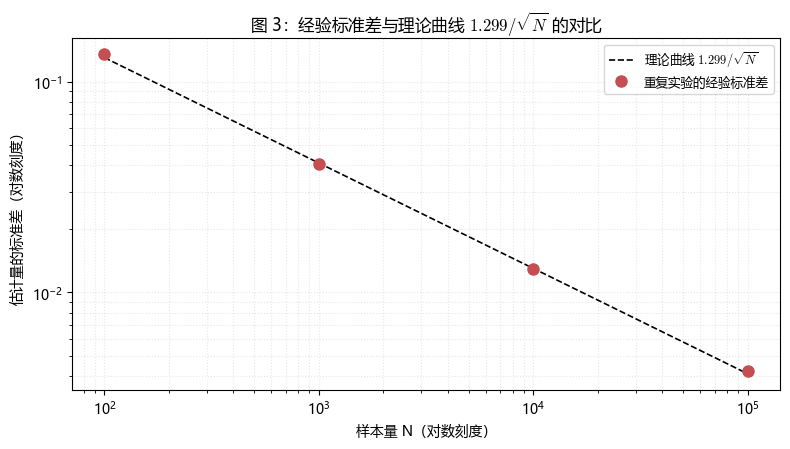

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.6))
N_line = np.logspace(2, 5, 200)
ax.plot(N_line, SIGMA_THEORY / np.sqrt(N_line), color="black", linestyle="--",
        linewidth=1.2, label=r"理论曲线 $1.299/\sqrt{N}$")
ax.plot([N for N in estimates], [v.std(ddof=1) for v in estimates.values()],
        "o", color="#c44e52", markersize=8, label=r"重复实验的经验标准差")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("样本量 N（对数刻度）")
ax.set_ylabel("估计量的标准差（对数刻度）")
ax.set_title("图 3：经验标准差与理论曲线 $1.299/\\sqrt{N}$ 的对比")
ax.grid(alpha=0.3, which="both", linestyle=":")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

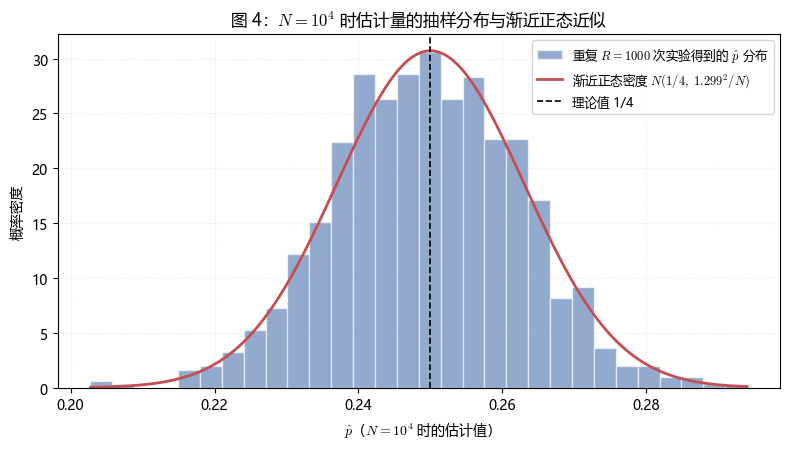

In [7]:
vals = estimates[10**4]
sd_th = SIGMA_THEORY / np.sqrt(10**4)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hist(vals, bins=30, density=True, color="#4c72b0", alpha=0.6, edgecolor="white",
        label=r"重复 $R=1000$ 次实验得到的 $\hat p$ 分布")
x = np.linspace(vals.min(), vals.max(), 400)
ax.plot(x, np.exp(-0.5 * ((x - P_THEORY) / sd_th) ** 2) / (sd_th * np.sqrt(2 * np.pi)),
        color="#c44e52", linewidth=2,
        label=r"渐近正态密度 $N(1/4,\ 1.299^2/N)$")
ax.axvline(P_THEORY, color="black", linestyle="--", linewidth=1.2, label="理论值 1/4")
ax.set_xlabel(r"$\hat p$（$N=10^4$ 时的估计值）")
ax.set_ylabel("概率密度")
ax.set_title("图 4：$N=10^4$ 时估计量的抽样分布与渐近正态近似")
ax.grid(alpha=0.3, linestyle=":")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 图 3 与图 4 的内容解释

- **图 3**：四个 $N$ 处的经验标准差（红点）几乎正好落在理论曲线 $1.299/\sqrt N$（黑色虚线）上；双对数坐标下这条曲线是直线，其斜率 $-1/2$ 就是"$1/\sqrt N$ 收敛速度"的图形表达——$N$ 每乘以 100，标准差只除以 10。
- **图 4**：$N=10^4$ 时 $\hat p$ 的抽样分布（蓝色直方图）与渐近正态密度 $N(1/4,\ 1.299^2/10^4)$（红色曲线）几乎重合；中心在 $1/4$，绝大部分概率落在 $\pm0.026$以内。这说明在 $N=10^4$ 这个量级上，可以用正态分布近似 $\hat p$ 的抽样误差，蒙特卡洛结果也就可以用"估计 ± 2 倍标准差"的形式报告。

## 5. 波动幅度的推导：$1.299/\sqrt N$ 从哪来（Delta 方法）

把每次实验的结果按"是否属于 $B$、是否属于 $A$"分成三类：

| 类别 | 含义 | 概率 |
| --- | --- | --- |
| 第 1 类 | $A\cap B$（和为 9 且第一次为 6） | $p_1=1/36$ |
| 第 2 类 | $B\setminus A$（和为 9 且第一次不是 6） | $p_2=3/36=1/12$ |
| 第 3 类 | 其余 | $p_3=1-p_1-p_2=8/9$ |

$N$ 次独立实验的三类计数 $(K_1,K_2,K_3)$ 服从多项分布 $\mathrm{Multinomial}(N;p_1,p_2,p_3)$（这里用到的仍是第 1 节的两条假设：每次实验内部按 $1/36$ 等可能，$N$ 次重复实验之间相互独立），而

$$\hat p_N=\frac{K_1}{K_1+K_2}=g\!\left(\frac{K_1}{N},\frac{K_2}{N}\right),
\qquad g(x,y)=\frac{x}{x+y}.$$

由多元中心极限定理，

$$\sqrt N\left(\left(\frac{K_1}{N},\frac{K_2}{N},\frac{K_3}{N}\right)-(p_1,p_2,p_3)\right)
\ \xrightarrow{\ d\ }\ N(0,\Sigma),
\qquad \Sigma=\mathrm{diag}(p)-pp^{\mathsf T}.$$

再用 **Delta 方法**（$g$ 在 $(p_1,p_2)$ 处连续可微，且 $p_1+p_2=1/9>0$）：

$$\sqrt N\left(\hat p_N-\frac14\right)\ \xrightarrow{\ d\ }\ N\!\left(0,\ \nabla g^{\mathsf T}\Sigma\,\nabla g\right).$$

梯度为 $\dfrac{\partial g}{\partial x}=\dfrac{y}{(x+y)^2}$，$\dfrac{\partial g}{\partial y}=-\dfrac{x}{(x+y)^2}$，在 $(p_1,p_2)$ 处

$$\nabla g=\left(\frac{p_2}{(p_1+p_2)^2},\ -\frac{p_1}{(p_1+p_2)^2},\ 0\right)
=\left(\frac{27}{4},\ -\frac{9}{4},\ 0\right).$$

代入 $\Sigma=\mathrm{diag}(p)-pp^{\mathsf T}$（第 3 分量与梯度相乘为 0），得

$$\nabla g^{\mathsf T}\Sigma\,\nabla g
=\left(\tfrac{27}{4}\right)^{2}p_1(1-p_1)+\left(\tfrac{9}{4}\right)^{2}p_2(1-p_2)
\underbrace{-\,2\Big(\tfrac{27}{4}\Big)\Big(-\tfrac{9}{4}\Big)p_1p_2}_{=\,+2\cdot\frac{27}{4}\cdot\frac{9}{4}\,p_1p_2}
=\frac{27}{16}=1.6875 .$$

因此

$$\mathrm{sd}(\hat p_N)\approx\sqrt{\frac{27}{16}}\cdot\frac{1}{\sqrt N}
=\frac{3\sqrt3}{4}\cdot\frac{1}{\sqrt N}\approx\frac{1.299}{\sqrt N}.$$

**两条解读：**

- **$1/\sqrt N$ 收敛速度**：$N$ 扩大 100 倍，误差（标准差）只缩小 10 倍；要让误差再减半，样本量必须乘 4。
- **常数 $1.299$ 的来源**：它比"把 $N$ 当成 $N$ 个有效样本"的 $\sqrt{p(1-p)}=\sqrt{3/16}\approx0.433$ 大 3 倍。原因是条件事件 $B$ 本身是随机的，平均只有 $N\cdot P(B)=N/9$ 个样本落在 $B$ 里：$\sqrt{9}=3$。有效样本量约为 $N/9$。

**小样本时的修正**：以上是渐近结论。由第 3 节的精确条件分布，$\hat p_N\mid K_B\sim \mathrm{Bin}(K_B,1/4)/K_B$，由全方差公式可算出

$$\mathrm{Var}(\hat p_N)=p(1-p)\,\mathrm{E}\!\left[\frac{1}{K_B}\right]
\ \ge\ \frac{p(1-p)}{\mathrm{E}[K_B]}=p(1-p)\cdot\frac{9}{N},$$

其中不等号来自 Jensen 不等式（$1/k$ 为凸函数）。所以小 $N$ 时真实波动略大于渐近值：$N=10^2$ 时 $\mathrm{E}[1/K_B]\approx0.0989$（而 $1/\mathrm{E}[K_B]=0.09$），于是精确标准差为 $\sqrt{0.1875\times0.0989}=0.1362$，比渐近值 $0.1299$ 大约 $5\%$；$N\to\infty$ 时 $1/K_B$ 集中于 $1/\mathrm{E}[K_B]$，修正消失，二者一致。

In [8]:
# 用代码复核上面的代数：三类多项分布 + Delta 方法
p = np.array([1 / 36, 3 / 36, 1 - 4 / 36])        # (A∩B, B\A, 其他)
grad = np.array([p[1] / (p[0] + p[1]) ** 2,       # ∂g/∂x = y/(x+y)²
                 -p[0] / (p[0] + p[1]) ** 2,      # ∂g/∂y = -x/(x+y)²
                 0.0])
Sigma = np.diag(p) - np.outer(p, p)               # 多项分布的渐近协方差（除以 N）
sigma2 = grad @ Sigma @ grad                      # Delta 方法给出的渐近方差
print(f"渐近方差 sigma^2 = {sigma2:.6f}   （27/16 = {27 / 16:.6f}）")
print(f"渐近标准差 sigma = {np.sqrt(sigma2):.6f}   （3*sqrt(3)/4 = {3 * np.sqrt(3) / 4:.6f}）")

渐近方差 sigma^2 = 1.687500   （27/16 = 1.687500）
渐近标准差 sigma = 1.299038   （3*sqrt(3)/4 = 1.299038）


## 6. 模拟与解析结果的一致性

把解析结果与模拟结果核对：

| 对象 | 解析结果 | 模拟结果 | 结论 |
| --- | --- | --- | --- |
| 点估计 | $P(A\mid B)=0.25$ | 单次四个 $N$ 见第 3 节表格；重复实验均值见第 4 节表格 | 在抽样误差内一致 |
| 波动幅度 | $\mathrm{sd}=1.299/\sqrt N$ | 经验标准差（第 4 节表格、图 3） | 几乎重合 |
| 分布形状 | 渐近正态 $N(1/4,\ 1.6875/N)$ | 图 4 的直方图与正态密度 | 一致 |
| $\pm2\mathrm{sd}$ 覆盖率 | $\approx0.9545$ | 第 4 节表格 coverage(2sd) 列 | 一致 |
| 单次比较的随机性 | $\Pr(N_2\ \text{更接近})=\frac{2}{\pi}\arctan\sqrt{N_2/N_1}$ | 第 7 节的独立重复验证 | 一致 |

四类定量对照——**均值、波动幅度、分布形状、覆盖率**——都吻合。举两个具体的对照：$N=10^3$ 时经验标准差 $0.0407$ 与理论值 $0.0411$ 相差不到 $1\%$，覆盖率 $0.954$ 与理论值 $0.9545$ 几乎相同；$N=10^4$ 时经验标准差 $0.0129$ 与理论值 $0.0130$ 同样相差不到 $1\%$。这说明概率模型与模拟实现没有系统性偏差，剩余差异都在蒙特卡洛抽样误差允许的范围内。

## 7. 为什么增加 $N$ 不保证"每一次都更接近"理论值

这是第 4 问的核心，分四层说明。

**（1）$\hat p_N$ 是随机变量，大数定律不承诺单调。**
大数定律的结论是：对任意 $\varepsilon>0$，$\Pr(|\hat p_N-1/4|>\varepsilon)\to0$。它描述的是**误差分布越来越集中在 0 附近**，而不是"误差本身在每次实验里都变小"。收敛完全允许某一次实现出现"反弹"——只要反弹发生的概率随 $N$ 增大而趋于 0。
即便在同一串随机数上做嵌套实验（$N=10^3$ 的样本是 $N=10^4$ 样本的前缀，信息只增不减），$\hat p_N$ 也没有单调性：新加入的样本既可能把估计拉向 $1/4$，也可能拉远。图 5 就是一条这样的轨迹。本次单次实验里 $10^2\to10^3$ 恰好发生了这种回弹：偏差从 $0.050$ 升到 $0.071$，虽然波动带本身在变窄。

**（2）不同 $N$ 的实验彼此独立，谈不上"进步"。**
本作业的四个 $N$ 来自四次相互独立的实验。$N=10^4$ 那次不会"记住"$N=10^3$ 那次的结果，两次实验之间不存在任何保证后者更准的机制。"$N$ 越大越准"是关于**误差分布**（标准差 $1.299/\sqrt N$）的陈述，不是关于某一次具体实现排序的陈述。

事实上，若把 $10^2\to10^3\to10^4\to10^5$ 看成一个"误差序列"，出现至少一次"回落"（后一个 $N$ 的误差更大）的概率超过一半（用独立种子快速统计约 $52\%$）。也就是说，"四个 $N$ 的估计逐次单调变准"反倒是少数情况——这正是不该拿单次数字比较大小的原因。

**（3）这个"不保证"可以精确量化：$N$ 更大反而更远是很常见的事件。**
设 $N_1<N_2$，两次**相互独立**实验的误差在 $N$ 较大时近似服从零均值正态分布，标准差之比为

$$\frac{\mathrm{sd}(\hat p_{N_2})}{\mathrm{sd}(\hat p_{N_1})}=\sqrt{\frac{N_1}{N_2}} .$$

记 $e_{N_2}=\sigma_{N_2}Z_2$，$e_{N_1}=\sigma_{N_1}Z_1$，其中 $Z_1,Z_2$ 是相互独立的标准正态。则

$$\Pr(|e_{N_2}|<|e_{N_1}|)
=\Pr\!\left(\frac{|Z_2|}{|Z_1|}<\sqrt{\frac{N_2}{N_1}}\right)
=\frac{2}{\pi}\arctan\sqrt{\frac{N_2}{N_1}},$$

其中第二步用到：两个独立标准正态的绝对值之比 $|Z_2|/|Z_1|$ 服从**半柯西分布**，分布函数为 $\frac2\pi\arctan x\ (x>0)$。

代入具体数字：

| 比较 | $\sqrt{N_2/N_1}$ | $\Pr(N_2\ \text{更接近})$ | 大 $N$ 反而更远 |
| --- | --- | --- | --- |
| $10^2$ 与 $10^3$（或 $10^3$ 与 $10^4$） | $\sqrt{10}\approx3.16$ | $\approx0.805$ | $\approx19.5\%$ |
| $10^2$ 与 $10^5$ | $\sqrt{1000}\approx31.6$ | $\approx0.980$ | $\approx2.0\%$ |

也就是说，即使样本量扩大到 10 倍，仍有约 **1/5** 的概率"大 $N$ 的估计反而离 $1/4$ 更远"；只有把 $N$ 的比值扩大到约 1000 倍，这个概率才压到 2% 左右——而它**永远小于 1**。

下面的代码用第 4 节的独立重复实验直接验证这个公式。运行结果：$10^3$ 与 $10^4$ 这一对的观测频率是 $0.797$（理论 $0.805$），$10^2$ 与 $10^3$ 是 $0.817$（理论 $0.805$），都很接近。$10^2$ 与 $10^5$ 的观测频率 $0.958$ 与理论 $0.980$ 偏离稍大，原因是公式要求两个误差都近似正态，而 $N=10^2$ 时 $K_B$ 平均只有约 11 个，$\hat p_{100}$ 的分布还很粗糙（取值只能是分母不超过 $K_B$ 的那些分数），偏离正态——这提示公式的适用范围：两个 $N$ 都要大到足以让正态近似成立。

**（4）一句话总结。**
增加 $N$ 是在**概率意义上**提高精度：误差的典型大小按 $1/\sqrt N$ 缩小，"更接近"成为大概率事件，但永远不排除个别实现变远。这正是 Monte Carlo 实验必须报告误差量级（如 $\pm2\times1.299/\sqrt N$）而不是只给一个数字的原因。

In [9]:
# 验证"更大的 N 更接近"的概率公式：把两组独立重复实验按下标配对
# （配对方式不影响独立性：两组随机数相互独立，见 rng_reps 的使用）
print(f"{'N1':>7} {'N2':>7} {'pairs':>6} {'freq(N2 closer)':>16} {'(2/pi)arctan(sqrt(N2/N1))':>26}")
for N1, N2 in [(10**2, 10**3), (10**3, 10**4), (10**2, 10**4), (10**2, 10**5)]:
    v1, v2 = estimates[N1], estimates[N2]
    m = min(len(v1), len(v2))
    freq = np.mean(np.abs(v2[:m] - P_THEORY) < np.abs(v1[:m] - P_THEORY))
    theory = 2 / np.pi * np.arctan(np.sqrt(N2 / N1))
    print(f"{N1:>7} {N2:>7} {m:>6} {freq:>16.3f} {theory:>26.3f}")

     N1      N2  pairs  freq(N2 closer)  (2/pi)arctan(sqrt(N2/N1))
    100    1000   2000            0.817                      0.805
   1000   10000   1000            0.797                      0.805
    100   10000   1000            0.928                      0.937
    100  100000    400            0.958                      0.980


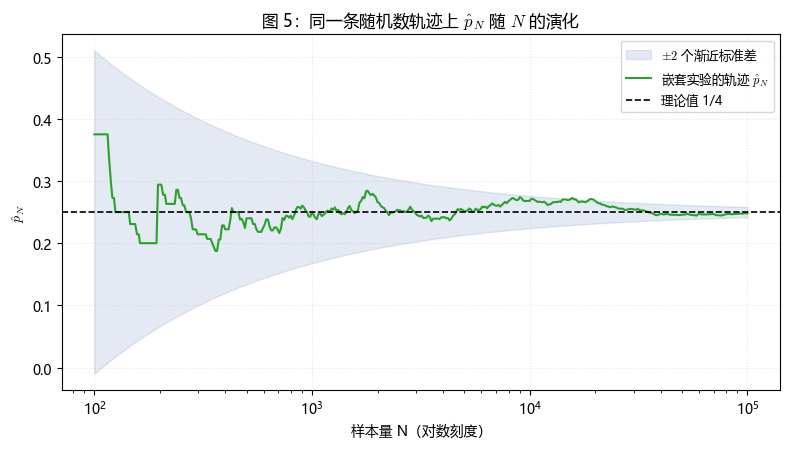

轨迹中『误差变大』的步数占比：0.388（若单调收敛应为 0）


In [10]:
# 嵌套轨迹：在同一串随机数上把 N 从 10^2 增加到 10^5，看 p̂ 的演化
rng_path = np.random.default_rng(2028)
N_max = 10**5
d1 = rng_path.integers(1, 7, size=N_max, dtype=np.int8)
d2 = rng_path.integers(1, 7, size=N_max, dtype=np.int8)
in_B = (d1 + d2) == 9
in_AB = in_B & (d1 == 6)
cum_B = np.cumsum(in_B)
cum_AB = np.cumsum(in_AB)

Ns_path = np.unique(np.round(np.logspace(2, 5, 400)).astype(int))
num, den = cum_AB[Ns_path - 1], cum_B[Ns_path - 1]
p_path = np.where(den > 0, num / np.maximum(den, 1), np.nan)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.fill_between(Ns_path, P_THEORY - 2 * SIGMA_THEORY / np.sqrt(Ns_path),
                P_THEORY + 2 * SIGMA_THEORY / np.sqrt(Ns_path),
                color="#4c72b0", alpha=0.15, label=r"$\pm2$ 个渐近标准差")
ax.plot(Ns_path, p_path, color="#2ca02c", linewidth=1.5,
        label=r"嵌套实验的轨迹 $\hat p_N$")
ax.axhline(P_THEORY, color="black", linestyle="--", linewidth=1.2, label="理论值 1/4")
ax.set_xscale("log")
ax.set_xlabel("样本量 N（对数刻度）")
ax.set_ylabel(r"$\hat p_N$")
ax.set_title("图 5：同一条随机数轨迹上 $\\hat p_N$ 随 $N$ 的演化")
ax.grid(alpha=0.3, linestyle=":")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()

inc = np.diff(np.abs(p_path - P_THEORY))
print(f"轨迹中『误差变大』的步数占比：{np.mean(inc > 0):.3f}（若单调收敛应为 0）")

### 图 5 的内容解释

- **绿线**：在**同一串随机数**上（$N$ 增大时保留已有样本、只在尾部追加），$\hat p_N$ 从 $N=10^2$ 走到 $N=10^5$ 的轨迹。这种"嵌套"比较排除了"不同实验之间无可比性"的干扰，是对"$N$ 增大是否必然更接近"最公平的检验。
- **蓝色带**：$\pm 2$ 个渐近标准差 $2\times1.299/\sqrt N$。轨迹基本待在带内，带子随 $N$ 按 $1/\sqrt N$ 收窄——均值意义上的收敛清晰可见。
- **不单调**：轨迹在 $1/4$ 上下连续抖动，上面打印的"误差变大的步数占比"明显大于 0，说明每一步都可能"变远"，即使在信息只增不减的嵌套实验里也是如此。
- **结论**：$N$ 的作用是把波动**按 $1/\sqrt N$ 压缩**，而不是让估计值沿单调路径逼近 $1/4$。任何单次实验都可能出现"$N$ 变大反而变远"的回弹；随 $N$ 增大，回弹的**幅度**变小、发生**大幅偏离**的概率变小，但"每一次都更接近"永远不成立。

## 8. 总结

- **模型**：公平骰子 + 两次投掷独立 $\Rightarrow$ 36 个有序结果等可能——这是所有"数格子"计算的前提。
- **解析结果**：$P(B)=4/36$，$P(A\cap B)=1/36$，故 $P(A\mid B)=1/4$；并且 $A$ 与 $B$ **不独立**（$1/36\ne1/54$），知道 $B$ 使 $A$ 的概率从 $1/6$ 升至 $1/4$。
- **模拟**：用 $K_{AB}/K_B$（两个频率之比）估计 $P(A\mid B)$，依据是强大数定律；模拟值在 $0.25$ 附近波动，重复实验的均值与 $0.25$ 在抽样误差内一致。
- **波动**：$\mathrm{sd}(\hat p_N)\approx1.299/\sqrt N$（Delta 方法），比朴素估计的 $0.433/\sqrt N$ 大 3 倍，代价是有效样本量只有约 $N/9$（只有约 $1/9$ 的样本落在条件事件 $B$ 里）。
- **关于第 4 问**：$N$ 增大只保证误差分布按 $1/\sqrt N$ 收窄，不保证每一次实现都更接近；两次独立实验之间"更大 $N$ 更接近"的概率为 $\frac2\pi\arctan\sqrt{N_2/N_1}$（$10^3$ 与 $10^4$ 之间约为 $80.5\%$），并非 $100\%$。因此报告模拟结果应给出误差量级，而不是依赖单次数字之间的大小比较。